# Q2

In [3]:
import cv2 # just for reading the image 
import numpy as np 
import matplotlib.pyplot as plt

read image "q2.png"

In [4]:
img = cv2.imread("q2.png", cv2.IMREAD_COLOR)
type(img)

numpy.ndarray

plot the image

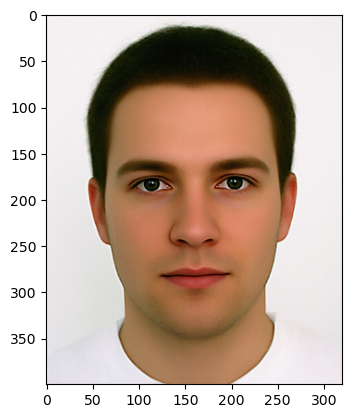

In [5]:
### YOUR CODE ###
# Convert the image from BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Display the image using matplotlib
plt.imshow(img_rgb)
plt.show()

In [6]:
type(img)

numpy.ndarray

In [7]:
def segment(image,seed_point,threshold,neighbor_mode=0):
    segmented_image = image.astype(np.int16)
    segmented_image -=  image[seed_point[0], seed_point[1]]

    height, width = image.shape[:2]
    visited = np.zeros((height, width), dtype=bool)
    result_mask = np.zeros((height, width), dtype=bool)

    check = [seed_point]
    visited[seed_point[0], seed_point[1]] = True

    if neighbor_mode == 0: ### => 4-connectivity
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    elif neighbor_mode == 1:
        neighbors = [(-1, 0), (1, 0), (0, -1), (0, 1),
                     (-1, -1), (-1, 1), (1, -1), (1, 1)] 
        
    while check:
        x,y = check.pop(0)
        result_mask[x,y] = 1

        for dx, dy in neighbors:
            if -1 < x+dx < height and -1 < y+dy < width and not visited[x+dx, y+dy]:
                diff = np.sum(np.abs(segmented_image[x+dx, y+dy]))
                
                if diff < threshold:
                    visited[x+dx, y+dy] = True
                    check.append([x+dx, y+dy])
                    
    segmented_image[result_mask==1] = [0, 0, 255]

    return segmented_image

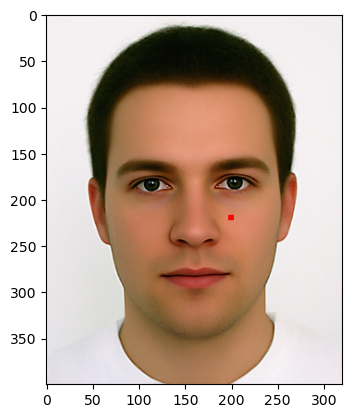

In [8]:
def show_pix(point):
    find_pix = img.copy()
    for i in range (-3, 3):
        for j in range(-3, 3):
            find_pix[point[0]+i, point[1]+j] = [0,0,255]
    # Convert the image from BGR to RGB
    find_pix = cv2.cvtColor(find_pix, cv2.COLOR_BGR2RGB)

    # Display the image using matplotlib
    plt.imshow(find_pix)
    plt.show()

seed_point= [220, 200]
show_pix(seed_point)
threshold= 10

In [ ]:
segmented_image_4 = segment(img,seed_point,threshold)
segmented_image_8 = segment(img,seed_point,threshold,1)

plot the results and compare them

In [ ]:
### YOUR CODE ###
# segmented_image_4_rgb = cv2.cvtColor(segmented_image_4, cv2.COLOR_BGR2RGB)
# segmented_image_8_rgb = cv2.cvtColor(segmented_image_8, cv2.COLOR_BGR2RGB)
plt.imshow(segmented_image_4)
plt.imshow(segmented_image_8)
plt.show()

error: OpenCV(4.6.0) ./modules/imgproc/src/color.simd_helpers.hpp:94: error: (-2:Unspecified error) in function 'cv::impl::{anonymous}::CvtHelper<VScn, VDcn, VDepth, sizePolicy>::CvtHelper(cv::InputArray, cv::OutputArray, int) [with VScn = cv::impl::{anonymous}::Set<3, 4>; VDcn = cv::impl::{anonymous}::Set<3, 4>; VDepth = cv::impl::{anonymous}::Set<0, 2, 5>; cv::impl::{anonymous}::SizePolicy sizePolicy = cv::impl::<unnamed>::NONE; cv::InputArray = const cv::_InputArray&; cv::OutputArray = const cv::_OutputArray&]'
> Unsupported depth of input image:
>     'VDepth::contains(depth)'
> where
>     'depth' is 3 (CV_16S)
